# Flickr30k Dataset Analysis with CLIP

This notebook demonstrates training and evaluation of the CLIP model on the Flickr30k dataset, including data preprocessing, model training, and performance analysis.

In [1]:
import torch

print("MPS available:", torch.backends.mps.is_available())
print("Device:", "mps" if torch.backends.mps.is_available() else "cpu")


MPS available: True
Device: mps


### Cell 2: Import dependencies

`import sys`


In [2]:
import sys
!{sys.executable} -m pip uninstall numpy -y
!{sys.executable} -m pip install numpy==1.26.4



Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl (14.0 MB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Importing Libraries

This cell imports the necessary libraries for the notebook, such as PyTorch, NumPy, and other dependencies required for data processing and model training.

In [3]:
import numpy as np
print(np.__version__)


1.26.4


In [4]:
pip install "datasets>=2.10,<2.18"


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 

## Data Loading

In [5]:
from datasets import load_dataset

dataset = load_dataset("nlphuji/flickr30k")

dataset


/Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    test: Dataset({
        features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
        num_rows: 31014
    })
})

In [6]:
dataset["test"][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500>,
 'caption': ['Two young guys with shaggy hair look at their hands while hanging out in the yard.',
  'Two young, White males are outside near many bushes.',
  'Two men in green shirts are standing in a yard.',
  'A man in a blue shirt standing in a garden.',
  'Two friends enjoy time spent together.'],
 'sentids': ['0', '1', '2', '3', '4'],
 'split': 'train',
 'img_id': '0',
 'filename': '1000092795.jpg'}

In [7]:
full_dataset = dataset["test"]
print(len(full_dataset))


31014


### Splits the Dataset into Train / Val / Test
This cell shuffles the full dataset with a fixed seed for reproducibility, then splits it into training (80%), validation (10%), and test (10%) subsets. The sizes of each split are printed to confirm the split proportions.

In [8]:
full_dataset = full_dataset.shuffle(seed=42)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset = full_dataset.select(range(train_size))
val_dataset = full_dataset.select(range(train_size, train_size + val_size))
test_dataset = full_dataset.select(range(train_size + val_size, len(full_dataset)))

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
   

Train: 24811
Val: 3101
Test: 3102


# ==========================================
# CONTROLLED TRAIN DATA (40K WITH 25K UNIQUE IMAGES)
# ==========================================


### Builds Controlled Training Pairs (One Caption Per Image)
This cell constructs a controlled training dataset by mapping each unique image to all of its captions, then selecting exactly one caption per image to form `unique_image_pairs`. The remaining captions are stored in `remaining_pairs` for optional augmentation. The number of unique images and remaining pairs are printed.

In [9]:
from collections import defaultdict
import random

image_to_captions = defaultdict(list)

# Step 1: Build mapping
for item in train_dataset:
    image = item["image"]
    captions = item["caption"]
    
    for caption in captions:
        image_to_captions[id(image)].append((image, caption))

print("Unique images:", len(image_to_captions))


# Step 2: Select 1 caption per image and store rest separately
unique_image_pairs = []
remaining_pairs = []

for image_id, captions_list in image_to_captions.items():
    
    # Randomly choose one caption for uniqueness
    chosen_pair = random.choice(captions_list)
    unique_image_pairs.append(chosen_pair)
    
    # Add the remaining captions directly (no comparison needed)
    for pair in captions_list:
        if pair != chosen_pair:
            remaining_pairs.append(pair)

print("Unique pairs:", len(unique_image_pairs))
print("Remaining pairs:", len(remaining_pairs))

Unique images: 24811
Unique pairs: 24811
Remaining pairs: 99229


### Samples Additional Caption Pairs
This cell randomly selects 15,189 additional image-caption pairs from the remaining pool using a fixed seed. Combined with the unique image pairs, this brings the total training set to approximately 40K pairs.

In [10]:
# Step 4: Randomly select 15K additional pairs

random.seed(42)

additional_pairs = random.sample(remaining_pairs, 15189)

print("Additional pairs selected:", len(additional_pairs))

Additional pairs selected: 15189


In [11]:
# Step 5: Combine to make final 40K training dataset

final_train_pairs = unique_image_pairs + additional_pairs

random.shuffle(final_train_pairs)

print("Final training dataset size:", len(final_train_pairs))

Final training dataset size: 40000


In [12]:
from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


/Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [62]:
from torch.utils.data import Dataset

In [61]:
class FlickrDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
        
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        image, caption = self.pairs[idx]
        return image, caption


### Defines the Collate Function
This cell (re)initializes the `CLIPProcessor` and defines `collate_fn`, which unpacks a batch of image-caption pairs and uses the processor to tokenize the text and preprocess the images into padded tensors ready for model input.

In [63]:
from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def collate_fn(batch):
    images, captions = zip(*batch)
    
    inputs = processor(
        text=list(captions),
        images=list(images),
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    
    return inputs


In [64]:
from torch.utils.data import DataLoader

### Defines the Collate Function
This cell (re)initializes the `CLIPProcessor` and defines `collate_fn`, which unpacks a batch of image-caption pairs and uses the processor to tokenize the text and preprocess the images into padded tensors ready for model input.

In [65]:
# train_data = FlickrDataset(train_pairs)

# train_loader = DataLoader(
#     train_data,
#     batch_size=32,
#     shuffle=True,   
#     num_workers=0,
#     collate_fn=collate_fn
# )

train_pairs = final_train_pairs

train_data = FlickrDataset(train_pairs)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

### Defines the Collate Function
This cell (re)initializes the `CLIPProcessor` and defines `collate_fn`, which unpacks a batch of image-caption pairs and uses the processor to tokenize the text and preprocess the images into padded tensors ready for model input.

In [66]:
batch = next(iter(train_loader))

for key in batch:
    print(key, batch[key].shape)


input_ids torch.Size([32, 34])
attention_mask torch.Size([32, 34])
pixel_values torch.Size([32, 3, 224, 224])


In [67]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

batch = {k: v.to(device) for k, v in batch.items()}


# Phase 4


### Loads the Pretrained CLIP Model for Fine-Tuning
This cell detects the compute device, loads the `openai/clip-vit-base-patch32` CLIP model, moves

In [68]:
import torch
from transformers import CLIPModel

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model = model.to(device)

model.train()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [69]:
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['input_ids', 'attention_mask', 'pixel_values'])


## Validation

In [70]:
val_pairs = []

for item in val_dataset:
    image = item["image"]
    captions = item["caption"]
    
    for caption in captions:
        val_pairs.append((image, caption))

len(val_pairs)

15505

In [72]:
# ==========================================
# CONTROLLED TRAIN DATA (40K WITH 25K UNIQUE IMAGES)
# ==========================================

from collections import defaultdict
import random

# Step 1: Map each image to its captions
unique_val_pairs = defaultdict(list)

for item in val_dataset:
    image = item["image"]
    captions = item["caption"]
    
    for caption in captions:
        unique_val_pairs[id(image)].append((image, caption))

print("Unique images:", len(unique_val_pairs))

Unique images: 3101


In [73]:
# Step 2: Select 1 caption per unique image (25K pairs)

val_pairs = []

for image_id in unique_val_pairs:
    # randomly choose 1 caption per image
    pair = random.choice(unique_val_pairs[image_id])
    val_pairs.append(pair)

print("Unique image pairs:", len(val_pairs))

Unique image pairs: 3101


### Creates the Validation DataLoader
This cell wraps `val_pairs` in a `FlickrDataset` and loads it into a `DataLoader` with batch size 32, no shuffling, and the custom `collate_fn`. This loader is used for computing validation loss and recall during training.

In [74]:
val_data = FlickrDataset(val_pairs)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

### Defines the `compute_validation_loss` Function
This function evaluates the model on the validation set without updating weights. For each batch, it computes normalized image and text embeddings, scales the similarity matrix by the learned temperature (`logit_scale.exp()`), and calculates the symmetric contrastive loss. It returns the average validation loss across all batches.

In [ ]:
# device = "mps" if torch.backends.mps.is_available() else "cpu"

In [34]:
# model.eval()

In [ ]:
# model.logit_scale.requires_grad = True

In [75]:
len(val_pairs)

3101

In [76]:
val_data = FlickrDataset(val_pairs)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

In [77]:
len(val_pairs)

3101

In [58]:
# model.eval()

In [ ]:
# torch.save(model.state_dict(), "clip_learned_temp.pt")

# Load both models 

In [78]:
from transformers import CLIPModel

In [79]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model = model.to(device)

In [80]:
state_dict = torch.load("clip_fixed_temp.pt", map_location=device)
model.load_state_dict(state_dict)
model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [81]:
from transformers import CLIPModel
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

state_dict = torch.load("clip_learned_temp.pt", map_location=device)

model.load_state_dict(state_dict)
model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [82]:
fixed_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
fixed_model.load_state_dict(torch.load("clip_fixed_temp.pt"))

learned_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
learned_model.load_state_dict(torch.load("clip_learned_temp.pt"))

fixed_model.eval()
learned_model.eval()# 

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [83]:
fixed_tau = 1 / fixed_model.logit_scale.exp()
learned_tau = 1 / learned_model.logit_scale.exp()

print("Fixed τ:", fixed_tau.item())
print("Learned τ:", learned_tau.item())

Fixed τ: 0.07000000029802322
Learned τ: 0.009999998845160007


In [84]:
print(model.logit_scale.requires_grad)

True


In [85]:
import torch
import torch.nn.functional as F

def get_confidence_and_accuracy(model, loader):
    
    model.eval()
    
    confidences = []
    correctness = []
    
    with torch.no_grad():
        for batch in loader:
            
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(**batch)
            
            image_embeds = F.normalize(outputs.image_embeds, dim=1)
            text_embeds = F.normalize(outputs.text_embeds, dim=1)
            
            # similarity WITH temperature
            logit_scale = model.logit_scale.exp()
            logits = logit_scale * (image_embeds @ text_embeds.T)
            
            probs = F.softmax(logits, dim=1)
            
            conf, pred = probs.max(dim=1)
            
            labels = torch.arange(len(conf)).to(device)
            correct = (pred == labels).float()
            
            confidences.extend(conf.cpu().numpy())
            correctness.extend(correct.cpu().numpy())
    
    return confidences, correctness

In [86]:
conf_fixed, corr_fixed = get_confidence_and_accuracy(fixed_model, val_loader)
conf_learned, corr_learned = get_confidence_and_accuracy(learned_model, val_loader)

In [87]:
import numpy as np

def compute_ece(confidences, correctness, n_bins=5):
    
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        bin_lower = bins[i]
        bin_upper = bins[i+1]
        
        indices = [j for j in range(len(confidences))
                   if bin_lower <= confidences[j] < bin_upper]
        
        if len(indices) == 0:
            continue
        
        bin_conf = np.mean([confidences[j] for j in indices])
        bin_acc = np.mean([correctness[j] for j in indices])
        
        ece += (len(indices) / len(confidences)) * abs(bin_acc - bin_conf)
    
    return ece

In [88]:
ece_fixed = compute_ece(conf_fixed, corr_fixed)
ece_learned = compute_ece(conf_learned, corr_learned)

print("ECE Fixed:", ece_fixed)
print("ECE Learned:", ece_learned)

ECE Fixed: 0.06290201183501001
ECE Learned: 0.04048573951573573


In [89]:
import matplotlib.pyplot as plt

def calibration_curve(confidences, correctness, n_bins=5):
    
    bins = np.linspace(0, 1, n_bins + 1)
    
    bin_conf = []
    bin_acc = []
    
    for i in range(n_bins):
        indices = [j for j in range(len(confidences))
                   if bins[i] <= confidences[j] < bins[i+1]]
        
        if len(indices) == 0:
            continue
        
        bin_conf.append(np.mean([confidences[j] for j in indices]))
        bin_acc.append(np.mean([correctness[j] for j in indices]))
    
    return bin_conf, bin_acc

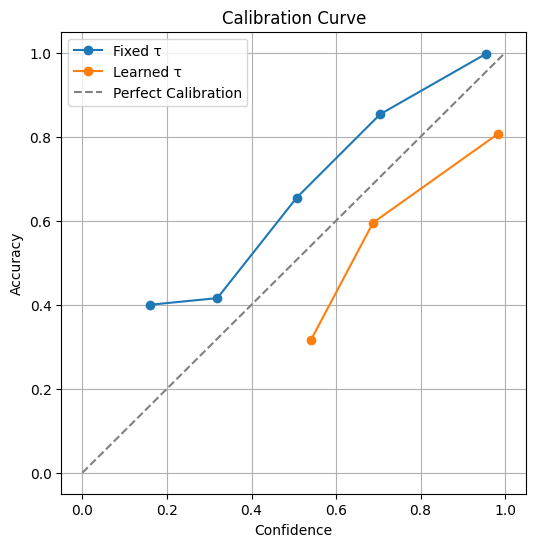

In [90]:
conf_f, acc_f = calibration_curve(conf_fixed, corr_fixed)
conf_l, acc_l = calibration_curve(conf_learned, corr_learned)

plt.figure(figsize=(6,6))

plt.plot(conf_f, acc_f, marker='o', label="Fixed τ")
plt.plot(conf_l, acc_l, marker='o', label="Learned τ")

plt.plot([0,1], [0,1], '--', color='gray', label="Perfect Calibration")

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Calibration Curve")
plt.legend()
plt.grid()

plt.show()

In [91]:
tau_fixed = 1 / fixed_model.logit_scale.exp()
tau_learned = 1 / learned_model.logit_scale.exp()

print("Fixed τ:", tau_fixed.item())
print("Learned τ:", tau_learned.item())

Fixed τ: 0.07000000029802322
Learned τ: 0.009999998845160007


In [92]:
def get_ood_loader(loader):
    
    ood_batches = []
    
    for batch in loader:
        batch = {k: v.clone() for k, v in batch.items()}
        
        # shuffle text inputs
        perm = torch.randperm(batch["input_ids"].size(0))
        batch["input_ids"] = batch["input_ids"][perm]
        batch["attention_mask"] = batch["attention_mask"][perm]
        
        ood_batches.append(batch)
    
    return ood_batches

In [93]:
ood_loader = get_ood_loader(val_loader)

conf_fixed_ood, corr_fixed_ood = get_confidence_and_accuracy(fixed_model, ood_loader)
conf_learned_ood, corr_learned_ood = get_confidence_and_accuracy(learned_model, ood_loader)

ece_fixed_ood = compute_ece(conf_fixed_ood, corr_fixed_ood)
ece_learned_ood = compute_ece(conf_learned_ood, corr_learned_ood)

print("OOD ECE Fixed:", ece_fixed_ood)
print("OOD ECE Learned:", ece_learned_ood)

OOD ECE Fixed: 0.8448697358840744
OOD ECE Learned: 0.21462310563745285


In [94]:
print("\n=== FINAL RESULTS ===")

print(f"Fixed τ: {tau_fixed.item():.4f}")
print(f"Learned τ: {tau_learned.item():.4f}")

print(f"\nECE Fixed: {ece_fixed:.4f}")
print(f"ECE Learned: {ece_learned:.4f}")

print(f"\nOOD ECE Fixed: {ece_fixed_ood:.4f}")
print(f"OOD ECE Learned: {ece_learned_ood:.4f}")


=== FINAL RESULTS ===
Fixed τ: 0.0700
Learned τ: 0.0100

ECE Fixed: 0.0629
ECE Learned: 0.0405

OOD ECE Fixed: 0.8449
OOD ECE Learned: 0.2146
